# Fase 1. Preparación del entorno experimental

Configuracion del entorno de trabajo en Jupyter, incluyendo la carga de librerías para procesamiento de modelos Vision-Language, manejo de imágenes, medición de recursos y evaluación de métricas. Se define además el dispositivo de ejecución (CPU/GPU) y se establece el modelo base sobre el cual se realizarán las pruebas, garantizando un entorno controlado y reproducible.

In [16]:
from pydantic import BaseModel, Field
from typing import Any


class GlobalObjectForContext(BaseModel):
    """A single re-identified object, ready for the context LLM phase.

    One per id_global; no duplicates across cameras.
    """

    id_global: str = Field(description="Global ReID identity")
    etiqueta: str = Field(description="Detection class label")
    confianza: float = Field(ge=0.0, le=1.0, description="Best confidence across views")
    contexto: str | None = Field(default=None, description="Natural-language context from LLM")
    sensores: dict[str, Any] = Field(default_factory=dict)
    cameras_seen: list[str] = Field(
        default_factory=list, description="Camera IDs that see this identity",
    )
    camera_id: str | None = Field(
        default=None, description="Representative camera (e.g. highest confidence)",
    )
    bbox: tuple[int, int, int, int] | None = Field(
        default=None,
        description="Representative bbox (xmin, ymin, xmax, ymax) from best view",
    )
    image_base64: str | None = Field(
        default=None,
        description="Base64-encoded image from best view",
    )


In [17]:
import transformers
print(transformers.__version__)
print(dir(transformers))

4.48.0
['ASTConfig', 'ASTFeatureExtractor', 'ASTForAudioClassification', 'ASTModel', 'ASTPreTrainedModel', 'Adafactor', 'AdamW', 'AdamWeightDecay', 'AdaptiveEmbedding', 'AddedToken', 'Agent', 'AlbertConfig', 'AlbertForMaskedLM', 'AlbertForMultipleChoice', 'AlbertForPreTraining', 'AlbertForQuestionAnswering', 'AlbertForSequenceClassification', 'AlbertForTokenClassification', 'AlbertModel', 'AlbertPreTrainedModel', 'AlbertTokenizer', 'AlbertTokenizerFast', 'AlignConfig', 'AlignModel', 'AlignPreTrainedModel', 'AlignProcessor', 'AlignTextConfig', 'AlignTextModel', 'AlignVisionConfig', 'AlignVisionModel', 'AltCLIPConfig', 'AltCLIPModel', 'AltCLIPPreTrainedModel', 'AltCLIPProcessor', 'AltCLIPTextConfig', 'AltCLIPTextModel', 'AltCLIPVisionConfig', 'AltCLIPVisionModel', 'AlternatingCodebooksLogitsProcessor', 'AqlmConfig', 'AriaConfig', 'AriaForConditionalGeneration', 'AriaImageProcessor', 'AriaPreTrainedModel', 'AriaProcessor', 'AriaTextConfig', 'AriaTextForCausalLM', 'AriaTextModel', 'AriaTex

In [18]:
import torch
import time
import psutil
import base64
from io import BytesIO
from PIL import Image
import pandas as pd
from transformers import AutoProcessor, AutoModelForImageTextToText
from evaluate import load
import matplotlib.pyplot as plt
import seaborn as sns

# Fase 2: Carga y configuración de modelos

Se implementa la carga de un modelo Vision-Language preentrenado como baseline, junto con versiones optimizadas del mismo mediante técnicas de reducción de complejidad (como cuantización y uso de precisión reducida). Esta fase permite establecer las distintas configuraciones experimentales que representan la variable independiente del estudio.

In [19]:
# ==============================
# 3. CONFIG
# ==============================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "Salesforce/blip-image-captioning-base"


In [20]:
# ==============================
# 4. LOAD MODEL (BASELINE)
# ==============================


processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = AutoModelForImageTextToText.from_pretrained(MODEL_NAME).to(DEVICE)

In [21]:
# ==============================
# 5. OPTIONAL: OPTIMIZED MODELS
# ==============================

# Quantized (CPU only)
model_quantized = torch.quantization.quantize_dynamic(
    model.cpu(), {torch.nn.Linear}, dtype=torch.qint8
)

# FP16 (GPU)
model_fp16 = None
# if DEVICE == "cuda":
    # model_fp16 = AutoModelForVision2Seq.from_pretrained(MODEL_NAME).half().to(DEVICE)

/tmp/ipykernel_15783/1208183660.py:6: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = torch.quantization.quantize_dynamic(


In [22]:
# ==============================
# 6. UTILS
# ==============================
def base64_to_image(base64_str):
    image_bytes = base64.b64decode(base64_str)
    return Image.open(BytesIO(image_bytes)).convert("RGB")


def measure_memory():
    return psutil.virtual_memory().used / (1024 ** 3)


def build_prompt(obj: GlobalObjectForContext):
    return f"Objeto: {obj.etiqueta}. Camaras: {', '.join(obj.cameras_seen)}. Describe la escena."


In [23]:
# ==============================
# 7. INFERENCE FUNCTION
# ==============================
def run_inference(obj: GlobalObjectForContext, model, processor, use_prompt=True):
    image = base64_to_image(obj.image_base64)
    
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    start_time = time.time()

    if use_prompt:
        inputs = processor(images=image, text=build_prompt(obj), return_tensors="pt").to(DEVICE)
    else:
        inputs = processor(images=image, return_tensors="pt").to(DEVICE)

    output = model.generate(**inputs)

    end_time = time.time()

    caption = processor.batch_decode(output, skip_special_tokens=True)[0]

    print(caption)

    return {
        "id_global": obj.id_global,
        "caption": caption,
        "latency": end_time - start_time,
        "memory": measure_memory()
    }

# Fase 3: Estructuración del input experimental

El sistema recibe como entrada un conjunto de objetos estructurados (simulando un pipeline previo de detección y reidentificación multicámara), donde cada objeto contiene información contextual e imágenes codificadas en base64. Se realiza la transformación de estos datos a un formato interpretable por el modelo, estableciendo la unidad de análisis del experimento.

In [24]:
# ==============================
# 8. DATASET
# ==============================

dataset: list[GlobalObjectForContext] = [
    GlobalObjectForContext(
        id_global="1",
        etiqueta="gato",
        confianza=0.92,
        cameras_seen=["cam1", "cam2"],
        camera_id="cam1",
        bbox=(100, 100, 200, 200),
        image_base64="UklGRuwUAABXRUJQVlA4IOAUAABwhQCdASraAQoBPp1OokylpCOwo9PZAhATiWdubvw5eyftGY1V4+f9jowHiUKUpZmKrSPq/Ee8s/u3SPsRs0ur4eZpPgHX+X2v+wDxp/S7lfuNu/spfFwzyCLhxSZ9x3g5GYpY2PgL1AG3ZFc/bxDn3jWYDxlpKbH8ZbKii4TnaPReHTbMSkRn8OyxoLgm7cuxf7fFysoms5jQU4e9tFJOzVLFUg5g6qQ7AjCIdzXlQSRvz+KHNRbG4WBhd4jfGN0wlEjrp6yjOw5mkeDrDDF8v0tHZDlRP/deatu+kFjjCigAMOTviug64FVOH3254Cidlb2zQCr4qR2NQZ2vgMhkKRqOCZvmZ8IP/vlxz+5vDgwe3/l8IeC9Gs/gMdRRjTP6GT4y4P70K3l/r5JPbuLytQnwpkic2w11ngbbLF4+C0qmgA/ZnPTwGYhmv9dp7mOO8QiaCb+tnIsfdGe1Fu3SjRoVAso+59HQKa+VLyiiotgciYAgnNGv5yn7BQT12XZEryz5ETiO8ZecgzLiTQXvoLg6xTV6JJwg6jUbcgOAz82xjEd871BnOVAfbEZQ5mlvdkt/iPuBHSyE1qYDUg8Biwkw+VDvsAEjBU8eqpxzysw5ZOfSe4aa1Y72qn/EfbAXsCnsJ1A5kdsZ9s7bLhaY+u/k/tiJx2OQBVcUWx3ZKbIrJQHzJFBqogzy+LQpyc4B/J88ACovoBWJMd86cUuj6ZdKuGzIiuDVsNaDbaxWm/1ICQsDmxVJU8wI7xskM19CF/+YPMnVs7DiuVF53FvmV71Xto+97eB+iiaUhQVP63kyWkBxOfKDfB0LbhW9m5BcYS1gjcP9Ueva6QYnsyJ61CjBz8Gc6auYhKlq5HBn2ycXjGvT//WEWlQAaabG2Dv6w37ayuU/xX9O37ixJjNJrnfxbfxPdx5Of31fulrZKu0SnzbXdSPIVAEaLpUyIZIhnQ29pDGDgXZwEay7snj0hPiUMCvCPIOOoo0sxp02gVzKmXDPsE9zG2ccLMTxP4GGm9rTmjJgDnq5kKjZdpbkaCIyWS45yJIUkG1BCjdOOJjj4AHU4AOduVOy7Q+SmbxklP658vcmsCc6WarRurH7ExkepJpnemLmmjslshKPxggeHD7GXsOwRF9S5bCbSEYJUS7TbvpHe0PFjVtsnbq/7ESlggeHSmSkH0O+8X1JxTgy/ZP2kwmR4xQwPACkYbfnL+1rs8gwSLXuUfabDoVZMV1y3lEqcCjlCAHhqOGtLxnc4ktw9bdxXphLKKCRu5WKGX3u7aIGOrqcmUQu0GA9KR4ip9FUWgGTIAWj7oddW+dMa8BMyrk5v4C/AYtQcXZ1vDATPB/RTYQFWZoLaZ+pVY+ssmbDC/r74Vt4tAQPHnxaSbzJi9yxYA3IiiTrTxDQwoCu1aXayxPwM7n5GWou+yVQAAD+1wuZ/ob08G164ubIwH+R2EN2TuiqV+M/4NxDdkF12gmqDCixBTDcf6txdi7oi4U+5hhaU+iTglWme1a5tr6ebfYUA4Xycbobz8WV8ij3M+Mx74C32AFf0u41GG9H+ISzEMTe+br70cYwjrlLZhZ7OB0yPm8yMoqIiQJEEQ3VTde91WKY5L0BuwgaELKXHxffWcLRiJQMMPQH2xU4FojO81r/GIW1dYo8eFJrlYHMMeGBKnW0DxXQ/INOw+c2t8P/psnv5TVgGX0IQQkxUR3tFm4Q9l4Y4q6mQlQ12o8+P4BgxbSg7FgLnCe3ftWf1FOTVAHYtHNlwIujWrgC9BKbyhYff2ZJ7CfYRMrle9GehC48G8KE76b3h6T4p4WToY/gtc+5Wn4kseYRq3juE2CJsgQv1CoslkJ+NNZE7XxqLaF7XZkQ7srw2w+0riFTDSaZycv14gixhhLqQITqqYqUNrphdhzHE+rYTdVhzwb0Whf026x3iZUEgFZdaHHJ26tC5nZnhb77wL/OwVeRPQ/4lPFqMtMdeRM0F6rFR08X9ezK5IkgMumrO1gCY2Zk2Hu2U/B9OsKrue239CgxOA3i3GKMhvFqPBKtAtc4xhj0WRk0tiVURDpBGxn01HvWlZYa8bkR+Ig07j/aykpsb0HBHX2nUrRVIG9KllRYODlEnv3m9T8styLcjwlbodzmrsyp/HtHUNkWEurd/eHndQ/PgLSjEnUT5iQDbloa+Zy4Ss7myDqlBRedHBFU/D8TrRaiPbKyySUiwbq4RtF0/Ai7tckpyreNy1OwzbQHgs5zG7JlP51QBDSuNrdyrLbPVK2SYKplOjYQPY+XiF/uyCWoNFsY0eS3xPxiCrvU7/tqPTQ62gnVzCs+U5BUrnDRoIM2oeysODY3cDS3Wkq3tTCA5WTORB1JCUYmyVGzSVvdotEV+MxiK6hacH2yZGAPREHsOKp3QKxKdIbIxPFYgRQxHsPoJUuROxloJl7aV1WOwkTZpZ1dpc+bCRQMqfbKXoKLOW1ylCWsMM21lSBqb7AVPDVI3Ic0A7kfTVKCrboZpSWNCt25JhNPZVtELoM+sWDzp69oktXIaiwtVHp6S8f+0zBc/udbDKR1Az7gdME/j9+mQUPRg4TvXljUuqs11ksNvZf9e2yhBPQ6id+saGM+ZjH1UZHGhdY4rfR9jG93aHCp2Bc/3pFlekN/tMBNt/uCxvg4lGIBhPAIOgWW9NXvzjnPorPo+ehEKQTBjAiPO8gR888u7od868Ikak7wocPeSlSciz3hcfVdh55I1N4PbDP3IErNNr7DS8wvfHbfmPReNuyM9G1JVtK/UXPWo25L2tPSuFfTloSi/WUYV/UTqfTygLGuVg63ALedbzGYfaw11aYKEjBKkNfnGNewpvOkVIRJljGX0JhdF+8XBwwtFeAIOVsGRYBZbCwkBNe53u4/Cc6P+XQ++rlV9k1JX2vvB7wBwTHrHBXD3fIiw0tlMxwHjPJamulNTZ/rdz9bsIGEJ9j2DZlBOzrgN1Mrp9MIxlnaeyh0ne96n7tcVPzDPteoQazWa07QDHTu4+X/4hBb7pYj7b29TjjFGikwWzzO0uMX4NYhmMvAlDmwPx8wC+O5PdYeY8bu74xoxiCB/LEJUrXTo7Be/C3SokykFQPZq0uWNz7/9St7paxAjNfsJvhhQUj5iKLHJa6WqW7MR4FaIkXDtUhI+PmzzVqnPQIQ8CiIesKD10s/6JGz/Fd4Sqh4lXjGbXswNcwJiXxZ2OCTj7I/mqmo2KsteBUwZEMwcuHymfpOIAFi1KbDVj8v0kYzy3Zlcb6YXiVeGkBT/3NXu/GCsrUFs1IAGrT9wGan1GloRGZtXOxAtyAD9Q2WGWD2kfEy3gf0dmIZbryvcOFpt7pEy2Y/KbD/FbOzg8gHRWpZtrlHrciOtmbsjvvMC9ccuHmOoRQcQmVoKtPS95ZorihfhEBt6VryQTXDD/A7WeuGdYsoSHp0tPBqS1GBjD82AMJRjbm2/iQYe/yU+I6ASMzBN8peQoqKsrTMn/767KtKaskXiDFRIDNNir+dcqc3VcfHEtamJbXJgoWdVwdPo8FK1dHAo1UZeXYfLbIttJveH6v50A6P+cdgHWORjQ4DOXjgAZ25f1rKi5awEc2NVk8nZaS53R/SQQT5cO7gtzd4yqY9rQYLPAJyipgRldNm5sSFSrjva6v4p34AdQHzyBpYZVLHblGhG9dlaetTef1vdqRIG9/5msOGC+UIgsWbtSbiR5gme6VRrzcTz5iVeBO55EkdMp2YuknvXlwfcXd060SklZZJxEpiGJXeVegnx6Zd91vmYyarLF/bHAb3OENm4dEFo8BpGpg0AhcaYsRaF2Ot54EQ1F90EJMPDgxM7A9zA6touMkM/3CpWggNJVac/t9gEoopsuEwoDS0731Yk1xh/jUjHe/oX5grhlgfFizAQeNu9s7Cg0qqPC2x3VnBxosDHtjtQ0Jgqi3jDU6Bd6QAVdz9FhMm2HetdNGE4kCZjIx9YarRfBRaflM0dhwfitWo2wFUuLieDmLzdYX2B6dSZrdyVKr7lasdZ0Ne8hgNfuOv5IaK31P60snqwV8wGpFR5V7T1pDpGOz3oyZUpZb7sdGEuAZSzjYY9fXtZhwoQYXn3yrOgHf7s+V4d03ARCnBRUK4YWThWO9XGoq3xaxfwPhh6Yu9frz41/uRHNB1c105kIfF1/twbnuYZJOMF65v7EPO2Wwmgy2JmJGNMSg3iIjx662IyWNWa31UcplTp4w8iXNLZbrV3mxjYKD7xrAGhGyUNGEDnfCkXddZbIJmuLwQCfBnm07hu4g9ctRyxV0UeZom/JWyWPxPI/+omTLufuQBDpg2I99Vvc5+JxGp75E0rkJRorm571hsfIhQ3uqvWYMoG0+4j077CXQbkMGyDEw7wxEKRa3bSRjOFoDCdRzteX8XS0fW+rQ8cm4W+bKt/cHxlV0KnvCi85Y7feeR83LHgxqw93Vpvx+e4r/pG6KQX4u74zWWrwRe0DTEgr8hXbZbQYOwwRmBfTTXNS4El+Qn9gyxceijNm5/s8YZ3JmBjeiZ59dMKEJl1EbSgx2IdHT1LaJG3DWOGfamFFpya9T4v9MjTsfM8iDFX2Gcy9O3PCMGRcvB7L8JtohLUCadbfjAtpJxF3LiEZ0BlLSw2+81TAw5VNtR5RThxywnHpkcpsXFBGNUbuxOL3Vb56DTCgSjEFBjxwGzB4Tl1YpRd1X8XuUWvB/PW5DM5BPX9QGe+XQlGS2xaQC6nO06xX4/fWtQLhXH74ancZM5y9wN2RjPkwHxZiJPKgQ0FEkzQu9JiTZeFHipHPLR+8gCZNFBRdVJHs+GOBGPylzM3sBcC1i7HToSapg5DaOzJLwgTBbHCGUgIDXdRQKCKryZ8D5Ljn/A1Lq/YomCurctjoVB/gN+I/gt4nsX8lqKFmsmGlxecM+IiA+1Ot/D94aTl5hb5V25LKZgaJmdivRORZ88enK1P6AREBijlRXJHe/NhM69nk1rHE0TSCHecoUsJR++hkf7AQObbk88sCF5jnjL5J4wJ9p5wUw/5KIRI3K+Aw91vvQ6StiwJpgJpoZJW6lYKPbE7hQMhMBc5+TdXXdws2bfqv4Ux+S7OwAiHrmTqJ7rgRSVehf1vWXrccoksMN+Das4z5AoFG2hrlzw+PNimVyVMd6h3omLPJqnvDCDjDp21ivd5aAlUar4ZBcTOcjDuxyLOvNZC+rnIUXnHa0F0BNXKmzCQItiu40HQiykK5n+r+qy7cY285m4ybhq94loVCT3pxHVP6oz9k3PYRdxFc+/0XFFMPWHML6bUzLPbZTn3YlP1yzMXvqXexrD1wZFFVBGgdJk6hQtkghWbmfJX2mz9OVU5ad6vtuUIr6JQV4xIVV7evke9GLY2PQnRHtQviCIUpyG0/OChV++3GkTlj3V9qDag346omA7fk9IpHj/WWVK0Q6zwDfXpLU6JttBRyqbpSic71vS/RspWRtw2uAY0gLSshm2Et+DOllExfVSin6R7BeHYURVJzDgnOtKF9ZPWNkV93qgqzrKdvGz4sz7XLYklYH8NYs9dN3eEg1ADsmQ0wNqv7WD5Bfw/ew6qHTRDvdljKiF9xgNaKUSjk/fJfvwC7VMTPVBI53f+7MiuKj7YHpNE/SF6GSFl6HQRRVfFVAvbKuN3u2B2MPCAkSVpNJX/ZeNNmb2KkALPXffNiCB710lHD2LfDG1RB9+9w6V5OXw5nheiJsVhIhdWo/y0XURbPG5NnPwQPkERv05LWOfRzH2ybnwf0jF+cVnjb9wRF9hP33tXyEdloyinDKXtXY57HtLmIh7fRSI4trzKMQCEx57BqNN+6vaFuKVsA/CYyGUZDY+fWQ7wiOQsFET2hnKiMR3oGnUiaUVfDmnpYCMVB66SGv9YfbTtAUFG5oGLb8vfv80iQI7Hz9Fm+sdqywXKvQwi5YQXDJduq1LslVaEXlEQXCag1I789xloF8zfbt4I1Jaj3lCNn9Zx4848z+nrOV2FJ69UjT26xCe5ntox6Z3bY+6CSMhdTL0Sycil+clYod9dOKxYwARsxyvucR53CpJdKLQaosCyn6TXEZswHqvO5Rn8mo24y/99j8azF3tW+fcrSSPh0gygNB4QPFXSRU5QYhgpal6g5XfAT6HxTg0GNB2DYlReOt3A1skUBVY7BvuE/yRBLAuvXEsRnOykkNPb9VPncQwzLF1CtRmBIRvYpnB9sbcURd4V9tRh1wZy4y+CScKP8oZDTKBlaMGMn0fZbUtithTIRYBrcoPlB7En54q7FaMWhx6ga6zDJdPm/F87w5MxGrOiw/H702f+UBTsWy+R66JaPWM9d2cwBf2PPgxqJyRzWK92AtXYmnNjHHYWFpJB4k94HZOz3e/I5h8AN63e1V5g6lS2lsHyOOvIrC5xp4pxRcSqVwaLPeAOIyEk5TcGorEkQ8Ks9pIX8904g1TiypbTITJc/duD7lTKvlvoLxy4IzJZISKJtletvEhC8U4+h6nmMUJY5cZ8kgiLuc4DP1cOh0ttPnYAcvCFjXSNzbjHMHPBAjps4KR16XvHGN7n30nlvZBIJ74TdQoXDrDQKI9FATpXPEtr8RBzoMpDLXh/M2PmtsKN2pgkWJHgsqQY4DgseKP56oYF77FBF/vHu5E4b3T/95in5V8ixC8Onabb0DdTtNLq7conG6N8dEv6mShWgpvnPZHZiLY9xWOGAx4TJ6t8pa4vpiRPIpiafFjGdB1sOd9CntfiTS92jCWUo1k2wrG6zkAq7O5DM5UaXtvod4nWlyKBc90odPotE+bhDSyN3cv9dVnjK7g8s6dJyOPMGXfrSPmFcjUt8kV93vFu09cqU0Pn2Zw8ZzKs4iiKbzewL1ZtqaKoHYlD3vp/aWZ3kdqWBknMK5jCR71jDIGIXE9Qke73aDvd91XKbC9WfIeOO6hEXvjr9+RJEoDn0ezPOdRnO+9GjaE9zpIlH7u4Vf6O382qri/BKVtcJQW3NcRKDEikKFk8DhzY9l0FusPbOB3cVwQ7isTog1ENL/B3XWxCO3eGc32zcOon6Qgwvkkr9rIz02Lh8KFPDKRx8ssEO4Ha9NWiZ95b6WihfsM1qDbm76VMGMWEaK8t3q2prl/+SqEozo522NtjjtXL6jL2AAA",
        contexto="A black cat",
    ),
    GlobalObjectForContext(
        id_global="2",
        etiqueta="perro",
        confianza=0.95,
        cameras_seen=["cam1", "cam2"],
        camera_id="cam2",
        bbox=(100, 100, 200, 200),
        image_base64="...",
        contexto="A white dog",
    ),
    GlobalObjectForContext(
        id_global="2",
        etiqueta="Johel Arias",
        confianza=0.95,
        cameras_seen=["cam1", "cam2"],
        camera_id="cam2",
        bbox=(100, 100, 200, 200),
        contexto="A man and woman standing in front of a store with a small child on the floor",
        image_base64="...",
    ),
    GlobalObjectForContext(
        id_global="2",
        etiqueta="Book",
        confianza=0.95,
        cameras_seen=["cam1", "cam2"],
        camera_id="cam2",
        bbox=(100, 100, 200, 200),
        contexto="A man and woman standing in front of a store with a small child on the floor",
        image_base64="...",
    ),
]

In [25]:
# ==============================
# 9. GROUND TRUTH (VERY IMPORTANT)
# ==============================

# Each id_global must have a human-written correct description
GROUND_TRUTH = {
    "1": "a black cat peeking over a wooden table",
    "2": "a white dog sitting in the grass",
    "3": "a man and woman standing in front of a store with a small child on the floor",
    "4": "a note pad with a pen and a notebook"
}

In [26]:
# ==============================
# 10. METRICS
# ==============================
bleu = load("bleu")


def evaluate_results(results):
    predictions = []
    references = []

    for r in results:
        predictions.append(r["caption"])
        references.append([GROUND_TRUTH.get(r["id_global"], "")])
    
    score = bleu.compute(predictions=predictions, references=references)
    
    return score["bleu"]

# Fase 4: Ejecución de inferencia

Se desarrolla el proceso de inferencia del modelo sobre cada objeto, generando descripciones en lenguaje natural a partir de las imágenes asociadas. Durante esta ejecución se capturan métricas clave como latencia y uso de memoria, las cuales representan el comportamiento del modelo en términos de consumo de recursos computacionales.

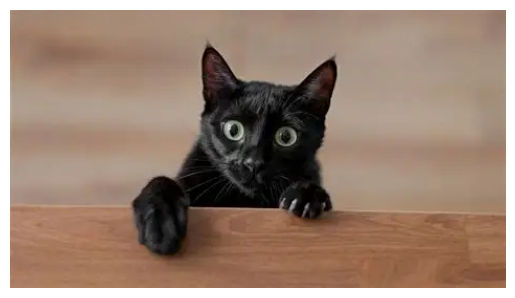

a black cat peeking over a wooden table


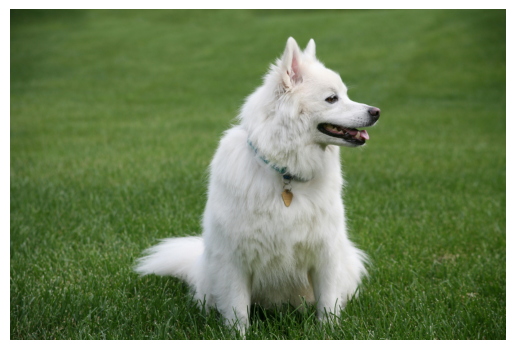

a white dog sitting in the grass


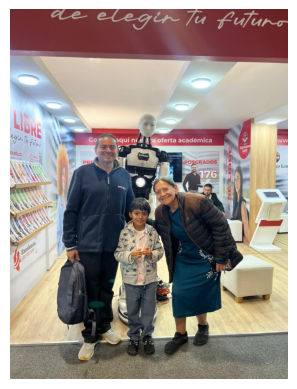

a man and woman standing in front of a store


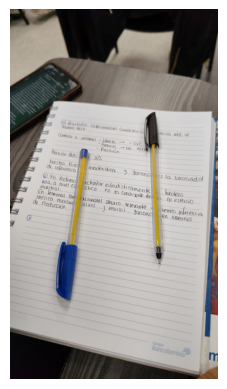

a note pad with a pen and a notebook


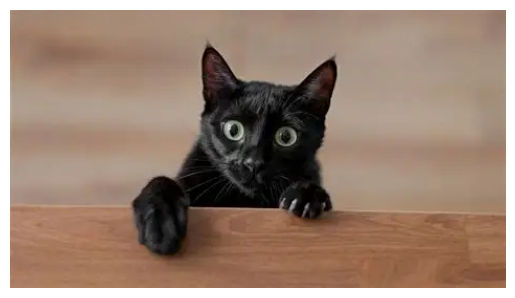

a black cat


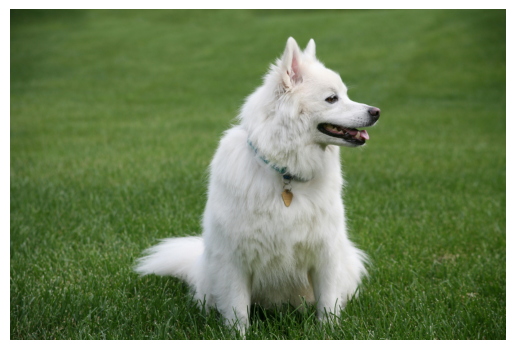

a white dog sitting in the grass


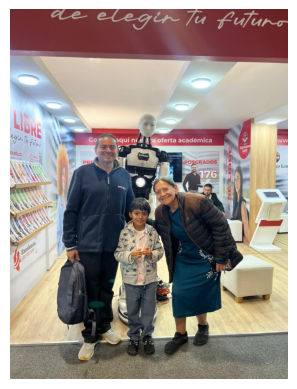

a man and a woman standing in a store


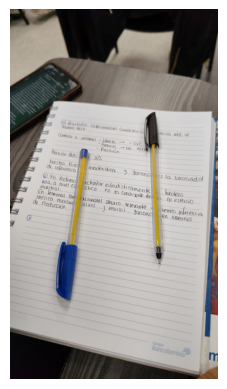

a note pad with a pen and a pen


In [27]:
# ==============================
# 10. RUN EXPERIMENTS
# ==============================


def run_experiment(model, name):
    results = []

    for obj in dataset:
        res = run_inference(obj, model, processor, False)
        res["model"] = name
        results.append(res)

    precision = evaluate_results(results)

    for r in results:
        r["precision"] = precision

    return results


# Run baseline
results_baseline = run_experiment(model, "baseline")

# Run quantized
results_quant = run_experiment(model_quantized, "quantized")

# Run fp16 if available
results_fp16 = []
if model_fp16:
    results_fp16 = run_experiment(model_fp16, "fp16")

# Fase 5: Evaluación de precisión

Se compara la salida generada por el modelo con descripciones de referencia (ground truth), utilizando métricas automáticas como BLEU para cuantificar la calidad semántica de las respuestas. Esta fase permite medir la variable dependiente principal del estudio: la precisión de las descripciones generadas.

In [28]:
# ==============================
# 12. MERGE
# ==============================
all_results = results_baseline + results_quant + results_fp16

df = pd.DataFrame(all_results)
df

,id_global,caption,latency,memory,model,precision
0,1,a black cat peeking over a wooden table,1.448184,5.228458,baseline,0.446389
1,2,a white dog sitting in the grass,1.448635,5.421162,baseline,0.446389
2,2,a man and woman standing in front of a store,1.560717,5.243149,baseline,0.446389
3,2,a note pad with a pen and a notebook,1.531199,5.241711,baseline,0.446389
4,1,a black cat,0.631513,5.242592,quantized,0.316717
5,2,a white dog sitting in the grass,1.121009,5.436989,quantized,0.316717
6,2,a man and a woman standing in a store,1.197563,5.303642,quantized,0.316717
7,2,a note pad with a pen and a pen,1.101030,5.308872,quantized,0.316717


# Fase 6: Análisis comparativo

Se consolidan los resultados en estructuras tabulares y visuales que permiten comparar el desempeño de cada configuración del modelo. Se generan métricas agregadas y gráficas que facilitan la identificación del impacto de la optimización sobre la relación entre precisión y consumo de recursos.

In [29]:
# ==============================
# 13. SUMMARY TABLE
# ==============================
summary = df.groupby("model").agg({
    "latency": "mean",
    "memory": "mean",
    "precision": "mean"
}).reset_index()

print("===== SUMMARY =====")
print(summary)

===== SUMMARY =====
       model   latency    memory  precision
0   baseline  1.497184  5.283620   0.446389
1  quantized  1.012779  5.323024   0.316717


# Fase 7: Interpretación del trade-off

Finalmente, el prototipo permite observar de forma empírica el equilibrio entre eficiencia computacional y calidad de salida, proporcionando evidencia para validar la hipótesis del estudio. Esta fase constituye el núcleo del experimento, al permitir determinar si es viable reducir recursos sin afectar significativamente la precisión.

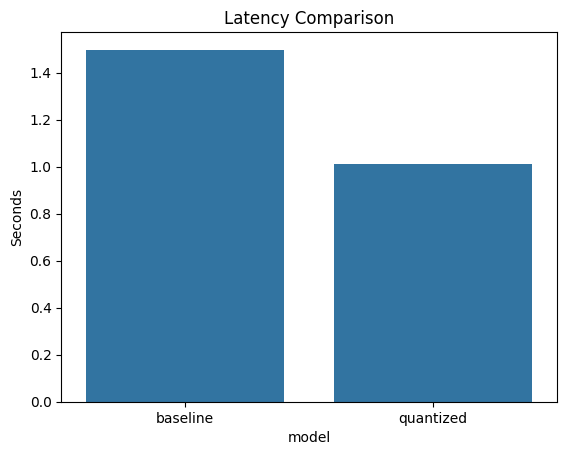

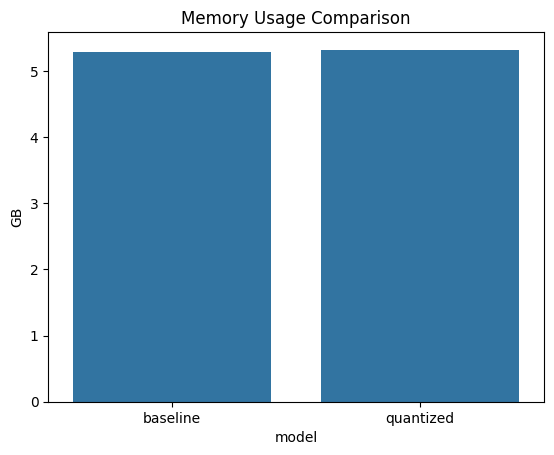

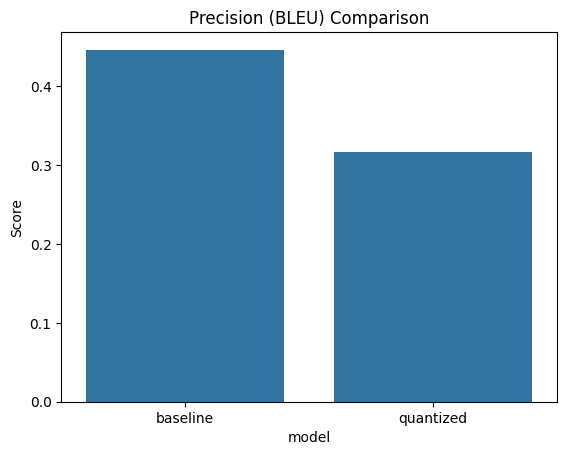

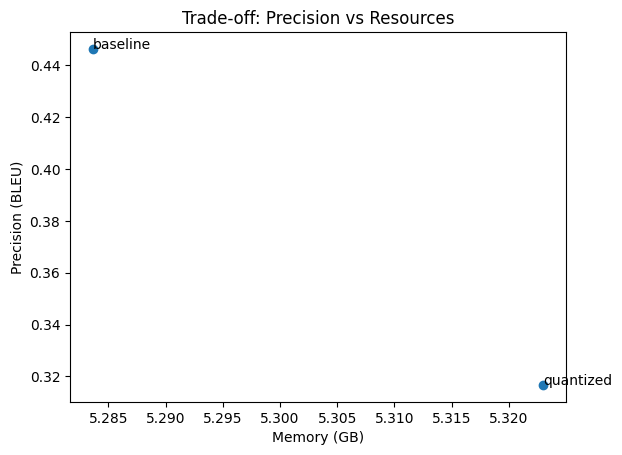

In [30]:
# ==============================
# 14. VISUALIZATION
# ==============================

# Latency comparison
plt.figure()
sns.barplot(data=summary, x="model", y="latency")
plt.title("Latency Comparison")
plt.ylabel("Seconds")
plt.show()

# Memory comparison
plt.figure()
sns.barplot(data=summary, x="model", y="memory")
plt.title("Memory Usage Comparison")
plt.ylabel("GB")
plt.show()

# Precision comparison
plt.figure()
sns.barplot(data=summary, x="model", y="precision")
plt.title("Precision (BLEU) Comparison")
plt.ylabel("Score")
plt.show()

# Trade-off plot (KEY GRAPH)
plt.figure()
plt.scatter(summary["memory"], summary["precision"])

for i, row in summary.iterrows():
    plt.text(row["memory"], row["precision"], row["model"])

plt.xlabel("Memory (GB)")
plt.ylabel("Precision (BLEU)")
plt.title("Trade-off: Precision vs Resources")
plt.show()